# Reducción de dimensionalidad — La Paz Traffic

Aplica PCA y UMAP sobre la matriz de features (250 × 72) para visualizar la estructura latente antes del clustering.

- **PCA**: varianza explicada, interpretación de componentes
- **UMAP**: proyección 2D para visualizar agrupaciones naturales

## 1. Imports y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from sklearn.decomposition import PCA
import umap

DATA_RAW       = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
TIPOS_DIA      = ['lunes', 'viernes', 'sabado']

# Cargar matriz normalizada
X = pd.read_csv(DATA_PROCESSED / 'feature_matrix_scaled.csv', index_col='segment_id')
X_raw = pd.read_csv(DATA_PROCESSED / 'feature_matrix.csv', index_col='segment_id')

print(f'Matriz cargada: {X.shape}')
print(f'Índices (segment_id): {X.index[:5].tolist()} ...')

/home/max1/ml/ProyNoSupervisados/venv_traffic/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Matriz cargada: (250, 72)
Índices (segment_id): [0, 1, 2, 3, 4] ...


## 2. PCA — Varianza explicada

Componentes para 80% varianza: 13
Componentes para 90% varianza: 19
Componentes para 95% varianza: 25


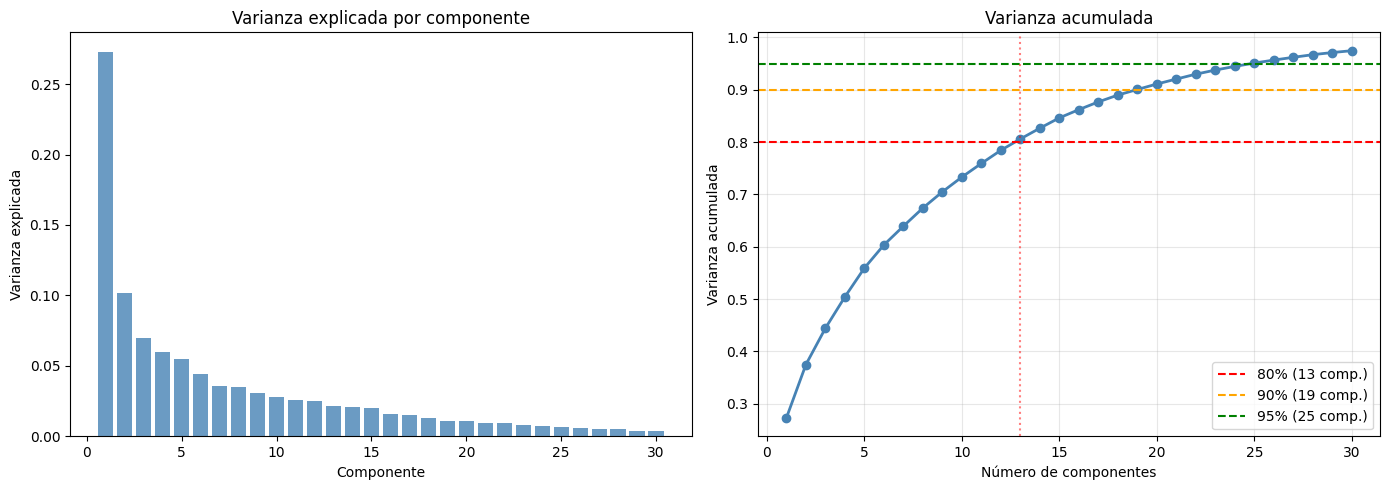

Guardado: data/processed/pca_variance.png


In [2]:
# Ajustar PCA completo para analizar varianza
pca_full = PCA(random_state=42)
pca_full.fit(X.values)

var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_80 = int(np.searchsorted(var_acum, 0.80)) + 1
n_90 = int(np.searchsorted(var_acum, 0.90)) + 1
n_95 = int(np.searchsorted(var_acum, 0.95)) + 1

print(f'Componentes para 80% varianza: {n_80}')
print(f'Componentes para 90% varianza: {n_90}')
print(f'Componentes para 95% varianza: {n_95}')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(30, len(var_acum))
axes[0].bar(range(1, n_show+1), pca_full.explained_variance_ratio_[:n_show],
            color='steelblue', alpha=0.8)
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada')

axes[1].plot(range(1, n_show+1), var_acum[:n_show], 'o-', color='steelblue', linewidth=2)
axes[1].axhline(0.80, color='red',    linestyle='--', label=f'80% ({n_80} comp.)')
axes[1].axhline(0.90, color='orange', linestyle='--', label=f'90% ({n_90} comp.)')
axes[1].axhline(0.95, color='green',  linestyle='--', label=f'95% ({n_95} comp.)')
axes[1].axvline(n_80, color='red', linestyle=':', alpha=0.5)
axes[1].set_title('Varianza acumulada')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Guardado: data/processed/pca_variance.png')

## 3. PCA — Interpretación de componentes

In [3]:
# Definir máscaras de patrones temporales
cols = list(X.columns)
patrones = {
    'matutino (6-9h)':   [c for c in cols if any(f'_{h:02d}' in c for h in range(6, 10))],
    'vespertino (16-19h)':[c for c in cols if any(f'_{h:02d}' in c for h in range(16, 20))],
    'nocturno (22-5h)':  [c for c in cols if any(f'_{h:02d}' in c for h in list(range(22,24))+list(range(0,6)))],
    'fin de semana':     [c for c in cols if c.startswith('jam_sabado')],
    'día hábil (lunes)': [c for c in cols if c.startswith('jam_lunes')],
}

loadings = pd.DataFrame(
    pca_full.components_[:5],
    columns=cols,
    index=[f'PC{i+1}' for i in range(5)]
)

print('Interpretación de los primeros 5 componentes principales:')
print('=' * 60)
for pc in loadings.index:
    correlaciones = {}
    for nombre, mascara in patrones.items():
        r = np.corrcoef(loadings.loc[pc, mascara].values,
                        np.ones(len(mascara)))[0,1]
        # Usar la magnitud media de los loadings en ese patrón
        correlaciones[nombre] = loadings.loc[pc, mascara].mean()
    mejor = max(correlaciones, key=lambda k: abs(correlaciones[k]))
    var_pc = pca_full.explained_variance_ratio_[int(pc[2:])-1] * 100
    print(f'{pc} ({var_pc:.1f}% var): loading más alto en "{mejor}" '
          f'(loading_mean={correlaciones[mejor]:.4f})')
    # Top 5 features con mayor loading absoluto
    top_feats = loadings.loc[pc].abs().nlargest(5).index.tolist()
    print(f'  Top features: {top_feats}')

Interpretación de los primeros 5 componentes principales:
PC1 (27.3% var): loading más alto en "vespertino (16-19h)" (loading_mean=0.1445)
  Top features: ['jam_viernes_15', 'jam_lunes_18', 'jam_lunes_13', 'jam_lunes_15', 'jam_viernes_19']
PC2 (10.2% var): loading más alto en "nocturno (22-5h)" (loading_mean=0.1158)
  Top features: ['jam_viernes_23', 'jam_sabado_05', 'jam_viernes_02', 'jam_sabado_21', 'jam_sabado_19']
PC3 (6.9% var): loading más alto en "nocturno (22-5h)" (loading_mean=0.0999)
  Top features: ['jam_viernes_22', 'jam_lunes_23', 'jam_sabado_10', 'jam_viernes_02', 'jam_sabado_23']
PC4 (6.0% var): loading más alto en "matutino (6-9h)" (loading_mean=-0.1004)
  Top features: ['jam_sabado_00', 'jam_lunes_01', 'jam_viernes_06', 'jam_sabado_09', 'jam_sabado_01']
PC5 (5.5% var): loading más alto en "matutino (6-9h)" (loading_mean=-0.0636)
  Top features: ['jam_viernes_18', 'jam_sabado_07', 'jam_lunes_04', 'jam_lunes_05', 'jam_sabado_08']


/home/max1/ml/ProyNoSupervisados/venv_traffic/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/max1/ml/ProyNoSupervisados/venv_traffic/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/max1/ml/ProyNoSupervisados/venv_traffic/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/max1/ml/ProyNoSupervisados/venv_traffic/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/max1/ml/ProyNoSupervisados/venv_traffic/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/max1/ml/ProyNoSupervisados/venv_traffic

In [4]:
# Proyección PCA con n_80 componentes y guardar
pca_n80 = PCA(n_components=n_80, random_state=42)
X_pca = pca_n80.fit_transform(X.values)

pca_df = pd.DataFrame(
    X_pca,
    index=X.index,
    columns=[f'PC{i+1}' for i in range(n_80)]
)
pca_df.index.name = 'segment_id'
pca_df.to_csv(DATA_PROCESSED / 'pca_embedding.csv')
print(f'Proyección PCA ({n_80} componentes) guardada: data/processed/pca_embedding.csv')
print(f'Varianza capturada: {pca_n80.explained_variance_ratio_.sum()*100:.1f}%')

Proyección PCA (13 componentes) guardada: data/processed/pca_embedding.csv
Varianza capturada: 80.6%


## 4. UMAP — Proyección 2D

In [5]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                    random_state=42, metric='euclidean')
X_umap = reducer.fit_transform(X.values)

umap_df = pd.DataFrame({
    'segment_id': X.index,
    'umap_x': X_umap[:, 0],
    'umap_y': X_umap[:, 1]
})
umap_df.to_csv(DATA_PROCESSED / 'umap_embedding.csv', index=False)
print(f'UMAP embedding guardado: data/processed/umap_embedding.csv')
print(f'Shape: {umap_df.shape}')

/home/max1/ml/ProyNoSupervisados/venv_traffic/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding guardado: data/processed/umap_embedding.csv
Shape: (250, 3)


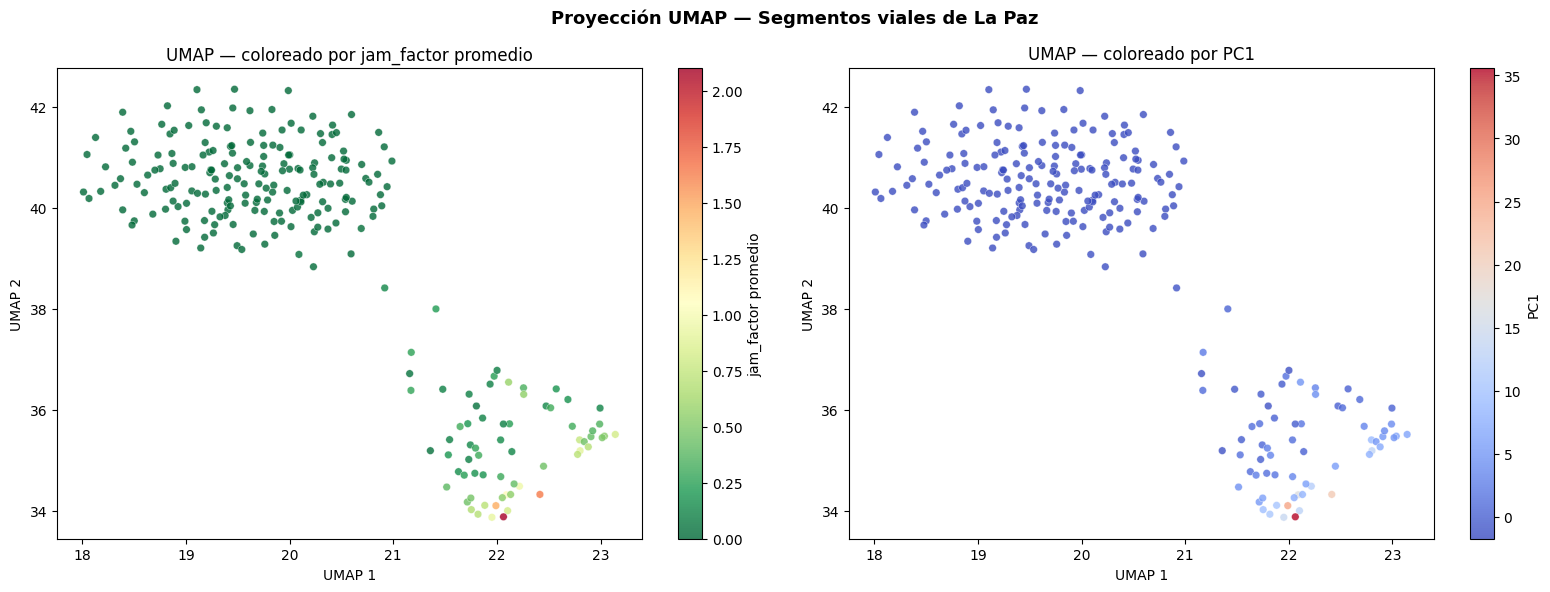

Guardado: data/processed/umap_preview.png


In [6]:
# jam_factor promedio por segmento (para colorear)
jam_mean = X_raw.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter coloreado por jam_factor promedio
sc = axes[0].scatter(
    umap_df['umap_x'], umap_df['umap_y'],
    c=jam_mean.values, cmap='RdYlGn_r',
    s=30, alpha=0.8, edgecolors='white', linewidths=0.3
)
plt.colorbar(sc, ax=axes[0], label='jam_factor promedio')
axes[0].set_title('UMAP — coloreado por jam_factor promedio')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# Scatter coloreado por PC1 (primer componente principal)
pc1_vals = X_pca[:, 0]
sc2 = axes[1].scatter(
    umap_df['umap_x'], umap_df['umap_y'],
    c=pc1_vals, cmap='coolwarm',
    s=30, alpha=0.8, edgecolors='white', linewidths=0.3
)
plt.colorbar(sc2, ax=axes[1], label='PC1')
axes[1].set_title('UMAP — coloreado por PC1')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

plt.suptitle('Proyección UMAP — Segmentos viales de La Paz', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'umap_preview.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: data/processed/umap_preview.png')

## 5. Resumen

**¿Los clusters son visualmente distinguibles en el espacio UMAP?**

Observá el scatter plot: si ves grupos separados de puntos (especialmente por color), el clustering formal va a funcionar bien. Una nube uniforme indicaría que todos los segmentos se comportan de forma similar.

Próximo paso: **FASE 7 — Clustering** (DBSCAN espacial + K-Means temporal).